In [1]:
import sys
sys.path.insert(1, '../src/')
from RipUOT import RipUOT
import torch
import numpy as np

/opt/anaconda3/envs/CRUOT_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = 1
np.random.seed(1) 
torch.manual_seed(1)
torch.use_deterministic_algorithms(True)


Subsample scGM

In [3]:
x_s_np = np.load("../datasets/scGM/X_scGM.npy") # scGM
x_s_np = np.float64(x_s_np)
type_expr = np.loadtxt("/Users/emapardini/Desktop/Github Projects/master-thesis/codes/datasets/scGM/scGM_typeExpression.txt") # scGM
type_expr = type_expr.astype(np.int64)

# --- Subsample the source data -----------
# Specify the proportions for each class
props_s = {
    1: 1.0,  
    2: 0.3,  
    3: 1.0,  
    4: 1.0,  
    5: 1.0   
}

subsets_s = []
labels_s = []

for cls, prop in props_s.items():
    # Get all indices for this class
    cls_indices = np.where(type_expr == cls)[0]
    n_samples = int(len(cls_indices) * prop)  # number to sample
    chosen = np.random.choice(cls_indices, n_samples, replace=False)
    subsets_s.append(x_s_np[chosen])
    labels_s.append(type_expr[chosen])

# Concatenate into a new dataset
x_s_sub = np.vstack(subsets_s)
labels_s_sub = np.hstack(labels_s)

x_s_sub = x_s_sub - x_s_sub.mean(axis=0)
# -------------------------------
row_norms_expr = np.linalg.norm(x_s_sub,  axis=1, keepdims=True)
row_norms_expr[row_norms_expr == 0] = 1
x_s_sub = x_s_sub / row_norms_expr
# -------------------------------
x_s = torch.tensor(x_s_sub, dtype=torch.float64)
type_expr = labels_s_sub.astype(np.int64)

In [4]:
x_t_np = np.load("../datasets/scGM/Y_scGM.npy") # scGM
x_t_np = np.float64(x_t_np)
type_methy = np.loadtxt("/Users/emapardini/Desktop/Github Projects/master-thesis/codes/datasets/scGM/scGM_typeMethylation.txt") # scGM
type_methy = type_methy.astype(np.int64)

props_t = {
    1: 1.0, 
    2: 1.0,  
    3: 1.0,  
    4: 0.3,  
    5: 1.0     
}

subsets_t = []
labels_t = []

for cls, prop in props_t.items():
    # Get all indices for this class
    cls_indices = np.where(type_methy == cls)[0]
    n_samples = int(len(cls_indices) * prop)  # number to sample
    chosen = np.random.choice(cls_indices, n_samples, replace=False)
    subsets_t.append(x_t_np[chosen])
    labels_t.append(type_methy[chosen])

x_t_sub = np.vstack(subsets_t)
labels_t_sub = np.hstack(labels_t)

# -------------------------------
row_norms_methy = np.linalg.norm(x_t_sub,  axis=1, keepdims=True)
row_norms_methy[row_norms_methy == 0] = 1
x_t_sub = x_t_sub / row_norms_methy
# -------------------------------
x_t = torch.tensor(x_t_sub, dtype=torch.float64)
type_methy = labels_t_sub.astype(np.int64)

In [5]:
device = torch.device("cpu")

x_s = x_s.to(device)
x_t = x_t.to(device)

In [6]:
ripuot = RipUOT(x_s, x_t, lambd=1.0, lambd_2=None, eps=5e-3, log=False)
ripuot.fit(k_cost=1.0, max_iter=100, tol=1e-6, max_iter_sinkhorn=10000, tol_sinkhorn=1e-6, device=device, verbose=True, log=False)

1
Sinkhorn stopped at iteration 839 with error 9.903152643486735e-07
Mean f: 0.010100065424875031 Mean g: -0.018781712245775146
error M: tensor(1.0834, dtype=torch.float64)
error P: tensor(0.0101, dtype=torch.float64)
2
Sinkhorn stopped at iteration 797 with error 9.941758782328058e-07
Mean f: -0.06185625742440768 Mean g: -0.09769941321373504
error M: tensor(0.3172, dtype=torch.float64)
error P: tensor(0.0156, dtype=torch.float64)
3
Sinkhorn stopped at iteration 599 with error 9.9328013278277e-07
Mean f: -0.08966498410576125 Mean g: -0.10429514768959447
error M: tensor(0.1750, dtype=torch.float64)
error P: tensor(0.0095, dtype=torch.float64)
4
Sinkhorn stopped at iteration 505 with error 9.968807026736193e-07
Mean f: -0.10795185506836351 Mean g: -0.10697243690078359
error M: tensor(0.1835, dtype=torch.float64)
error P: tensor(0.0080, dtype=torch.float64)
5
Sinkhorn stopped at iteration 519 with error 9.945780925640912e-07
Mean f: -0.12144755339628614 Mean g: -0.11123182592938587
error 

In [7]:
X_s, X_t = ripuot.align(eps_1=5e-3, max_iter_sinkhorn=10000, tol_sinkhorn=1e-6) # for scGM

Sinkhorn stopped at iteration 1240 with error 9.994956643444297e-07
Mean f: 0.21852973650476715 Mean g: -0.4429752073729736


In [8]:
import evals 

lta = evals.compute_lta(X_s.numpy(), X_t.numpy(), type_expr, type_methy, n=5)

print("LTA:", lta)

LTA: 0.6644295302013423


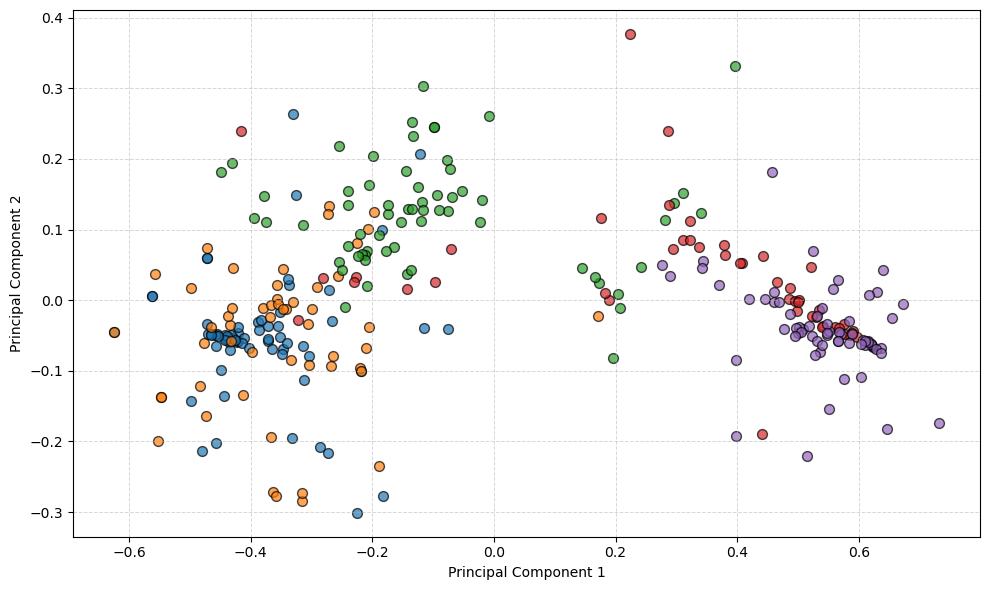

In [9]:
evals.plot_projection(
    source_proj=X_s.numpy(),    # your projected source domain (n_samples, d)
    source_labels=type_expr,    # true source labels (1D array)
    target_data=X_t.numpy(),    # your original target domain (n_samples, d)
    target_labels=type_methy,   # true target labels (1D array)
    method='pca',               # or 'umap'
    save_pdf=True
)